# Binary Dependent Variables: LPM, Logit & Probit. Lecture Notebook
### Applied Statistical Data Analysis. Prof. Dr. Kristyna Ters | MSc Finance | FHNW
**Based on:** Brooks, C., *Introductory Econometrics for Finance*, Cambridge University Press, Ch. 12

---
**Learning Objectives:**
- Understand why OLS struggles with 0/1 outcomes (the **LPM** and its defects)
- Estimate **logit** and **probit** models by maximum likelihood
- Interpret coefficients via **marginal effects** and **odds factors**
- Compute **default probabilities (PD)** per borrower with a probit
- Evaluate binary models with **pseudo-R-squared** and **hit rates**

> Run each cell with **Shift+Enter**. This notebook accompanies the V11 lecture slides.
> Both datasets are simulated with fixed seeds, calibrated so the estimates land close to the
> slide values. The slides use illustrative numbers; the code computes the seeded ones. They
> will be close, but not identical.

## Step 0: Install & Import Libraries

In [1]:
!pip install statsmodels --quiet

import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':'white', 'axes.facecolor':'white',
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.3, 'font.size':11
})
YELLOW = '#FDE70E'; ORANGE = '#FCB310'; RED = '#C70101'
GREY   = '#4B4B4B'; BLUE = '#0E75FE'; GREEN = '#0B7A3C'
print('Libraries loaded.')

Libraries loaded.


---
# Part 1: The Dividend Cross-Section

The running example of the video: **which firms pay dividends?** We simulate a cross-section of
500 US stocks with three characteristics: profitability (ROA in percent), size (log market cap)
and leverage (debt over assets, as a share between 0 and 1). The payer status is generated from
a logistic model with the lecture's coefficients (ROA +0.09, log size +0.85, leverage minus 2.1,
intercept minus 5.90), so the fitted estimates below reproduce the slide numbers closely.

### 1.1 Simulate the sample

In [2]:
rng = np.random.default_rng(378)   # seed chosen so the sample reproduces the lecture numbers
n = 500

roa = rng.normal(8, 5, n)                          # return on assets, in %
lnm = rng.normal(7.5, 1.3, n)                      # ln(market cap in millions)
lev = np.clip(rng.beta(2.2, 4.8, n), 0.01, 0.95)   # leverage share

index_true = -5.90 + 0.09*roa + 0.85*lnm - 2.1*lev
p_true = 1/(1 + np.exp(-index_true))               # logistic CDF
payer = rng.binomial(1, p_true)

df = pd.DataFrame({'payer': payer, 'roa': roa, 'ln_mcap': lnm, 'leverage': lev})
print(df.describe().round(3))
print(f"\nPayers: {payer.sum()} of {n}  ({payer.mean():.1%})")

         payer      roa  ln_mcap  leverage
count  500.000  500.000  500.000   500.000
mean     0.622    8.025    7.494     0.303
std      0.485    5.001    1.334     0.171
min      0.000   -8.442    4.167     0.013
25%      0.000    4.637    6.580     0.165
50%      1.000    8.020    7.448     0.271
75%      1.000   11.594    8.363     0.421
max      1.000   23.523   11.205     0.853

Payers: 311 of 500  (62.2%)


**Check the benchmark first.** The unconditional payer share is about 62 percent. That number
does double duty: it is the probability the constant-only model assigns to everyone, and it is
the hit rate of the naive strategy "predict payer for every firm". Every model below must beat it.

The odds of paying: 0.62/0.38 is about 1.63 to one, i.e. paying is 1.63 times as likely as not
paying. Odds return as the natural language of logit coefficients in Part 4.

---
# Part 2: The Linear Probability Model, Briefly

Just run OLS on the 0/1 outcome. Each coefficient is then a probability change per unit of x.
Legitimate as a quick first look, but watch its three defects: predictions outside [0, 1],
built-in heteroskedasticity (the error variance of a 0/1 outcome is p(1 minus p) by construction,
so robust standard errors are mandatory), and constant effects everywhere on the probability scale.

### 2.1 Fit the LPM with robust standard errors

In [3]:
X = sm.add_constant(df[['roa', 'ln_mcap', 'leverage']])
lpm = sm.OLS(df['payer'], X).fit(cov_type='HC1')   # White robust SEs, as in the diagnostics video
print(lpm.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5147      0.115     -4.480      0.000      -0.740      -0.290
roa            0.0168      0.004      4.632      0.000       0.010       0.024
ln_mcap        0.1501      0.013     11.831      0.000       0.125       0.175
leverage      -0.4044      0.118     -3.441      0.001      -0.635      -0.174


In [4]:
fitted = lpm.fittedvalues
n_above = (fitted > 1).sum()
n_below = (fitted < 0).sum()
print(f"Fitted values outside [0, 1]: {n_above} above 1, {n_below} below 0")
print(f"Range of fitted values: {fitted.min():.3f} to {fitted.max():.3f}")

Fitted values outside [0, 1]: 24 above 1, 1 below 0
Range of fitted values: -0.006 to 1.284


**Reading.** The LPM slope on ROA says: one more point of ROA adds about 2 percentage points of
payer probability, for every firm alike. Keep the LPM coefficients in mind; they approximate the
average marginal effects of Part 5, which is the sense in which the LPM is a decent first look.
The out-of-band predictions are the broken part: a probability of 1.1 or minus 0.05 does not exist.

---
# Part 3: Logit & Probit

Keep the linear index x'beta, but pass it through a CDF so the result always lands in (0, 1):
the logistic CDF gives the **logit**, the standard normal CDF gives the **probit**. Estimation is
by maximum likelihood: choose the betas that make the observed 0/1 pattern most probable.
Inference works through z-statistics (asymptotic normality), compared with 1.96 exactly like
t-statistics in large samples.

### 3.1 Fit both models

In [5]:
logit = sm.Logit(df['payer'], X).fit(disp=0)
probit = sm.Probit(df['payer'], X).fit(disp=0)
print(logit.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -5.6500      0.749     -7.544      0.000      -7.118      -4.182
roa            0.0922      0.022      4.200      0.000       0.049       0.135
ln_mcap        0.8312      0.096      8.686      0.000       0.644       1.019
leverage      -2.1671      0.618     -3.508      0.000      -3.378      -0.956


In [6]:
compare = pd.DataFrame({
    'logit': logit.params.round(3),
    'probit': probit.params.round(3),
    'ratio logit/probit': (logit.params/probit.params).round(2),
})
print(compare)
print("\nRule of thumb: logit is roughly 1.6 times probit (same S-curve, different scale).")

          logit  probit  ratio logit/probit
const    -5.650  -3.362                1.68
roa       0.092   0.055                1.68
ln_mcap   0.831   0.497                1.67
leverage -2.167  -1.332                1.63

Rule of thumb: logit is roughly 1.6 times probit (same S-curve, different scale).


**Reading the table.** Signs and significance first, that reading is always safe: profitable and
large firms pay, heavily levered firms do not, and all three z-statistics clear 1.96. The raw
logit betas are INDEX effects, not probability effects; how much the probability moves depends on
where the firm sits on the S-curve. Hence the two translation languages of the next two parts:
odds factors and marginal effects.

---
# Part 4: The Odds Language

Odds are P/(1 minus P). In the logit, odds equal e to the power x'beta EXACTLY, so each unit of a
regressor multiplies the odds by the constant factor e to the beta. This exactness is why logit
results can be communicated in odds language (and probit results cannot).

### 4.1 Odds factors

In [7]:
odds_factors = np.exp(logit.params)
tab = pd.DataFrame({'coefficient': logit.params.round(3),
                    'odds factor e^beta': odds_factors.round(3)})
print(tab)

b_roa = logit.params['roa']
b_lev = logit.params['leverage']
print(f"\nEach ROA point multiplies the odds of paying by {np.exp(b_roa):.3f}"
      f"  (+{(np.exp(b_roa)-1)*100:.1f} percent)")
print(f"A 10-point leverage increase multiplies the odds by {np.exp(b_lev*0.10):.3f}"
      f"  ({(np.exp(b_lev*0.10)-1)*100:.1f} percent)")

          coefficient  odds factor e^beta
const          -5.650               0.004
roa             0.092               1.097
ln_mcap         0.831               2.296
leverage       -2.167               0.115

Each ROA point multiplies the odds of paying by 1.097  (+9.7 percent)
A 10-point leverage increase multiplies the odds by 0.805  (-19.5 percent)


**Two-step discipline for the leverage number:** coefficient TIMES the change first (minus 2.1
times 0.10), exponentiate second. Exponentiating the raw coefficient would answer a 0-to-1 jump of
leverage, i.e. 100 percentage points, not 10. And remember the log regressor: the 0.85 on ln(mcap)
reads as an elasticity of the odds, roughly +0.85 percent odds per 1 percent more market cap.

---
# Part 5: Marginal Effects, What You Should Report

Chain rule: the probability effect of x is the coefficient times the slope of the S-curve at the
firm's position, for the logit simply P(1 minus P). The reporting standard is the **average
marginal effect (AME)**: compute the effect for every firm, then average.

### 5.1 AME in one line

In [8]:
ame = logit.get_margeff(at='overall')
print(ame.summary())

        Logit Marginal Effects       
Dep. Variable:                  payer
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
roa            0.0166      0.004      4.480      0.000       0.009       0.024
ln_mcap        0.1494      0.012     12.544      0.000       0.126       0.173
leverage      -0.3896      0.106     -3.670      0.000      -0.598      -0.182


In [9]:
ame_tab = pd.DataFrame({'AME': ame.margeff.round(4), 'LPM coefficient': lpm.params[1:].round(4)},
                       index=['roa', 'ln_mcap', 'leverage'])
print(ame_tab)
print("\nThe LPM coefficients approximate the AME: that is the precise sense in which")
print("the LPM is a legitimate quick look.")

             AME  LPM coefficient
roa       0.0166           0.0168
ln_mcap   0.1494           0.1501
leverage -0.3896          -0.4044

The LPM coefficients approximate the AME: that is the precise sense in which
the LPM is a legitimate quick look.


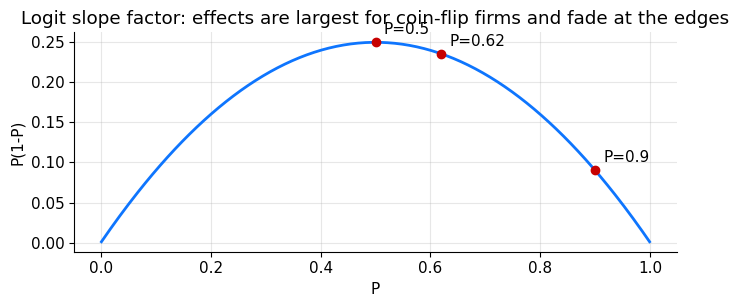

In [10]:
# The slope factor P(1-P): a bell that peaks at P = 0.5
P = np.linspace(0.001, 0.999, 300)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(P, P*(1-P), color=BLUE, lw=2)
for pt in [0.5, 0.62, 0.9]:
    ax.scatter([pt], [pt*(1-pt)], color=RED, zorder=5)
    ax.annotate(f"P={pt}", (pt, pt*(1-pt)), textcoords='offset points', xytext=(6, 6))
ax.set_xlabel('P'); ax.set_ylabel('P(1-P)')
ax.set_title('Logit slope factor: effects are largest for coin-flip firms and fade at the edges')
plt.tight_layout(); plt.show()

---
# Part 6: Second Example, Default Probabilities (PD)

Credit risk is where these models live in practice. We simulate 2000 corporate borrowers with
leverage and interest coverage (ICR = EBIT over interest expense) and generate defaults from a
probit with the lecture's coefficients: PD = Phi(minus 1.65 + 2.0 leverage minus 0.10 ICR).
The probit convention (normal CDF Phi) is standard in credit-risk and Basel IRB work.

### 6.1 Simulate and fit

In [11]:
rng2 = np.random.default_rng(83)    # seed chosen so the sample reproduces the lecture numbers
m = 2000
lev_b = np.clip(rng2.normal(0.35, 0.13, m), 0.02, 0.90)
icr_b = np.clip(rng2.lognormal(np.log(9.5), 0.50, m), 0.3, 30)

pd_true = norm.cdf(-1.65 + 2.0*lev_b - 0.10*icr_b)
default = rng2.binomial(1, pd_true)

borrowers = pd.DataFrame({'default': default, 'leverage': lev_b, 'icr': icr_b})
print(f"Defaults: {default.sum()} of {m}  ({default.mean():.1%})")

Xb = sm.add_constant(borrowers[['leverage', 'icr']])
pd_probit = sm.Probit(borrowers['default'], Xb).fit(disp=0)
print(pd_probit.summary().tables[1])

Defaults: 66 of 2000  (3.3%)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.7127      0.236     -7.268      0.000      -2.175      -1.251
leverage       2.0680      0.482      4.291      0.000       1.123       3.013
icr           -0.1040      0.019     -5.613      0.000      -0.140      -0.068


### 6.2 The deliverable: a PD per borrower

The fitted probability itself is the answer. Two example borrowers from the slides:
borrower A (leverage 0.20, ICR 8) and borrower B (leverage 0.60, ICR 1.5).

In [12]:
examples = pd.DataFrame({'leverage': [0.20, 0.65], 'icr': [8.0, 1.5]}, index=['A', 'B'])
Xe = sm.add_constant(examples, has_constant='add')

pd_hat = pd_probit.predict(Xe)
index_slide = -1.65 + 2.0*examples['leverage'] - 0.10*examples['icr']
pd_slide = norm.cdf(index_slide)

out = pd.DataFrame({'index (slide coefficients)': index_slide.round(2),
                    'PD (slide coefficients)': (pd_slide*100).round(1),
                    'PD (fitted model)': (pd_hat*100).round(1)})
out.columns = ['index', 'PD slide (%)', 'PD fitted (%)']
print(out)
print("\nBorrower B pays a far higher spread than borrower A: this number drives loan")
print("pricing, rating grades and regulatory capital (Basel IRB).")

   index  PD slide (%)  PD fitted (%)
A  -2.05           2.0            1.7
B  -0.50          30.9           30.0

Borrower B pays a far higher spread than borrower A: this number drives loan
pricing, rating grades and regulatory capital (Basel IRB).


---
# Part 7: How Good Is the Model? Pseudo-R-squared and Hit Rates

No residual variance, no ordinary R-squared. The ML yardstick is the log-likelihood: McFadden's
pseudo-R-squared compares the fitted model with the constant-only model. Values of 0.2 to 0.4
already indicate a strong binary model, and it is NOT explained variance.

### 7.1 McFadden for the dividend logit

In [13]:
print(f"log-likelihood fitted model : {logit.llf:.1f}")
print(f"log-likelihood constant-only: {logit.llnull:.1f}")
print(f"McFadden pseudo-R2          : {logit.prsquared:.3f}")

log-likelihood fitted model : -267.7
log-likelihood constant-only: -331.5
McFadden pseudo-R2          : 0.193


### 7.2 The confusion table and hit rate (cutoff 0.5)

In [14]:
pred = (logit.predict(X) > 0.5).astype(int)
conf = pd.crosstab(df['payer'], pred, rownames=['actual'], colnames=['predicted'])
print(conf)

hit = (pred == df['payer']).mean()
naive = df['payer'].mean()
print(f"\nHit rate : {hit:.1%}")
print(f"Naive    : {naive:.1%}  (predict 'payer' for everyone)")
print(f"Payers caught    : {conf.loc[1, 1] / conf.loc[1].sum():.1%}")
print(f"Non-payers caught: {conf.loc[0, 0] / conf.loc[0].sum():.1%}")

predicted    0    1
actual             
0          103   86
1           56  255

Hit rate : 71.6%
Naive    : 62.2%  (predict 'payer' for everyone)
Payers caught    : 82.0%
Non-payers caught: 54.5%


### 7.3 The unbalanced-sample trap, live

Apply the same cutoff-0.5 logic to the PD sample with its 3 percent event rate and watch the
headline hit rate mislead.

In [15]:
pred_b = (pd_probit.predict(Xb) > 0.5).astype(int)
print(f"Predicted defaults at cutoff 0.5: {pred_b.sum()} of {m}")
print(f"Hit rate  : {(pred_b == borrowers['default']).mean():.1%}")
print(f"Naive     : {1 - borrowers['default'].mean():.1%}  (predict 'no default' for everyone)")
caught = ((pred_b == 1) & (borrowers['default'] == 1)).sum()
print(f"Defaulters caught: {caught} of {borrowers['default'].sum()}")

# a cutoff at the sample share catches far more defaulters, at the cost of false alarms
cut = borrowers['default'].mean()
pred_c = (pd_probit.predict(Xb) > cut).astype(int)
caught_c = ((pred_c == 1) & (borrowers['default'] == 1)).sum()
false_c = ((pred_c == 1) & (borrowers['default'] == 0)).sum()
print(f"\nCutoff at the sample share ({cut:.3f}):")
print(f"Defaulters caught: {caught_c} of {borrowers['default'].sum()},  false alarms: {false_c}")

Predicted defaults at cutoff 0.5: 0 of 2000
Hit rate  : 96.7%
Naive     : 96.7%  (predict 'no default' for everyone)
Defaulters caught: 0 of 66

Cutoff at the sample share (0.033):
Defaulters caught: 52 of 66,  false alarms: 682


**Read both rows, not just the total.** With rare events, the all-safe prediction scores a
near-perfect hit rate and is useless. Choose the cutoff from the cost ratio of the two errors;
in credit scoring, a missed default costs the loan, a false alarm costs a review.

---
# Summary

- For a 0/1 outcome the regression models a probability: E[y|x] = P(y=1|x)
- The LPM is a quick first look; its defects push us to logit and probit
- Maximum likelihood chooses the betas that make the observed pattern most probable; z-statistics
- Report average marginal effects, and odds factors e^beta where useful (logit only)
- The fitted probability is the deliverable: PD drives pricing, ratings, regulatory capital
- Evaluate with McFadden pseudo-R-squared and hit rates against the naive benchmark

**Reading:** Brooks, Chapter 12. **Next:** Time Series I, stationarity and unit roots.